In [6]:
import zipfile

zip_path = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon-20260409T152509Z-3-001.zip" # Changed to include .zip extension
extract_path = "/content/drive/MyDrive/AI and Machine Learning"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Task 1: Data Understanding & Visualization

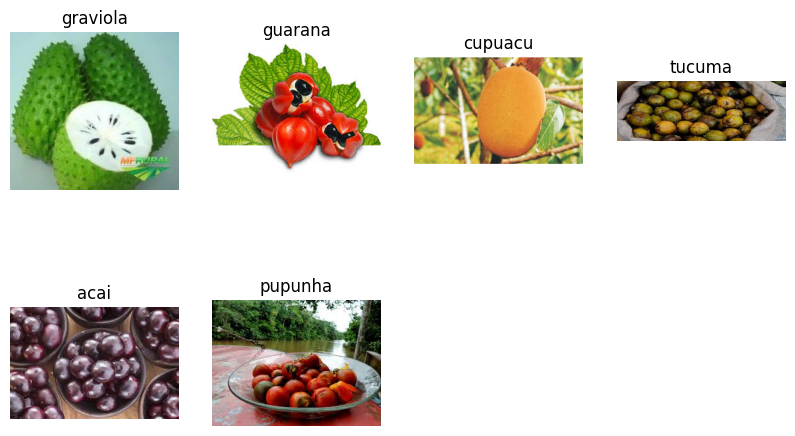

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/train"

classes = os.listdir(train_dir)

plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    img_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(img_path))
    img = Image.open(os.path.join(img_path, img_name))

    plt.subplot(2, len(classes)//2 + 1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

What did you observe?

*   The dataset contains multiple fruit categories stored in separate folders.
*   Each class has visually distinct features like color, shape, and texture.
*   Some images may have variations in lighting, angle, and background.
*   This variation helps the CNN learn robust features.





Task 1 (Part 2): Check Corrupted Images

In [9]:
from PIL import Image
import os

train_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/train"
corrupted = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


Task 2: Load & Preprocess Data

In [10]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3: CNN Model

In [11]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input # Corrected import for Input layer

num_classes = len(os.listdir(train_dir))

model = models.Sequential([
    Input(shape=(img_height, img_width, 3)), # Explicit Input layer
    layers.RandomFlip("horizontal_and_vertical"), # Added Data Augmentation
    layers.RandomRotation(0.2), # Added Data Augmentation
    layers.RandomZoom(0.2), # Added Data Augmentation
    layers.Conv2D(32, (3,3), padding='same', activation='relu'), # Removed input_shape
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

Task 4: Compile Model

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 5: Train Model

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.1655 - loss: 1.9391

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 464ms/step - accuracy: 0.1528 - loss: 2.0303 - val_accuracy: 0.1667 - val_loss: 2.4971
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.1626 - loss: 2.1748

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 393ms/step - accuracy: 0.2222 - loss: 2.0101 - val_accuracy: 0.1111 - val_loss: 1.9687
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.2228 - loss: 1.7257

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 385ms/step - accuracy: 0.2778 - loss: 1.6812 - val_accuracy: 0.1667 - val_loss: 1.7766
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.3478 - loss: 1.5781

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 378ms/step - accuracy: 0.4028 - loss: 1.5476 - val_accuracy: 0.2778 - val_loss: 1.7185
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step - accuracy: 0.4444 - loss: 1.4193 - val_accuracy: 0.2778 - val_loss: 1.7676
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step - accuracy: 0.4861 - loss: 1.2975 - val_accuracy: 0.3333 - val_loss: 2.0720
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 328ms/step - accuracy: 0.4861 - loss: 1.3391 - val_accuracy: 0.3889 - val_loss: 1.7273
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.5498 - loss: 1.1590

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 372ms/step - accuracy: 0.6111 - loss: 1.0296 - val_accuracy: 0.3889 - val_loss: 1.4803
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 365ms/step - accuracy: 0.7083 - loss: 0.8293 - val_accuracy: 0.4444 - val_loss: 1.5091
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 343ms/step - accuracy: 0.7222 - loss: 0.8245 - val_accuracy: 0.4444 - val_loss: 1.5722
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 349ms/step - accuracy: 0.7361 - loss: 0.6914 - val_accuracy: 0.4444 - val_loss: 1.9381
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 347ms/step - accuracy: 0.7083 - loss: 0.7079 - val_accuracy: 0.5000 - val_loss: 1.6184
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - accuracy: 0.7639 - loss: 0.6737 - val_accuracy: 0.4444 - val_loss: 1.7334
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.7847 - loss: 0.6048

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 393ms/step - accuracy: 0.7917 - loss: 0.6279 - val_accuracy: 0.5556 - val_loss: 1.4445
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 505ms/step - accuracy: 0.7778 - loss: 0.5389 - val_accuracy: 0.5000 - val_loss: 1.6389
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 350ms/step - accuracy: 0.8333 - loss: 0.4755 - val_accuracy: 0.4444 - val_loss: 1.6966
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.7541 - loss: 0.5016

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 392ms/step - accuracy: 0.7778 - loss: 0.4911 - val_accuracy: 0.5556 - val_loss: 1.3818
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step - accuracy: 0.8472 - loss: 0.4590 - val_accuracy: 0.5556 - val_loss: 1.6547
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 0.7917 - loss: 0.5786 - val_accuracy: 0.4444 - val_loss: 1.9517
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.7807 - loss: 0.5599

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 372ms/step - accuracy: 0.7639 - loss: 0.5889 - val_accuracy: 0.5556 - val_loss: 1.2716
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8600 - loss: 0.4290

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step - accuracy: 0.8611 - loss: 0.4374 - val_accuracy: 0.6111 - val_loss: 1.1743
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.7778 - loss: 0.4969 - val_accuracy: 0.5000 - val_loss: 1.2819
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 433ms/step - accuracy: 0.7778 - loss: 0.4692 - val_accuracy: 0.3889 - val_loss: 1.5344
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 497ms/step - accuracy: 0.8750 - loss: 0.3506 - val_accuracy: 0.5000 - val_loss: 1.5900
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - accuracy: 0.8333 - loss: 0.3874 - val_accuracy: 0.5000 - val_loss: 1.6314
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 352ms/step - accuracy: 0.8889 - loss: 0.2843 - val_accuracy: 0.4444 - val_loss: 1.5084
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - accuracy: 0.9167 - loss: 0.2658 - val_accuracy: 0.5000 - val_loss: 1.6314
Epoch 29/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step - accuracy: 0.9167 - loss: 0.2478 - val_accuracy: 0.5556 - val_lo

Task 6: Evaluate Model

In [14]:
test_loss, test_acc = model.evaluate(val_ds)
print("Accuracy:", test_acc)
print("Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.6111 - loss: 1.1743
Accuracy: 0.6111111044883728
Loss: 1.174345850944519


Task 7: Save & Load Model

In [15]:
model.save("cnn_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("cnn_model.h5")

loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.6111 - loss: 1.1743


[1.174345850944519, 0.6111111044883728]

Task 8: Prediction + Classification Report

In [16]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.50      0.50      0.50         2
           2       0.75      1.00      0.86         3
           3       0.67      0.80      0.73         5
           4       0.50      0.25      0.33         4
           5       0.50      0.33      0.40         3

    accuracy                           0.61        18
   macro avg       0.57      0.65      0.58        18
weighted avg       0.59      0.61      0.58        18



Graphs

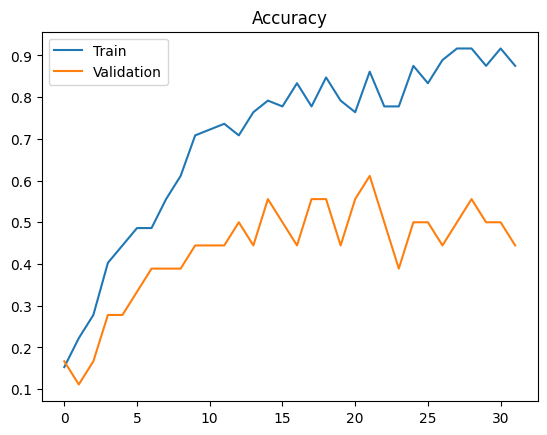

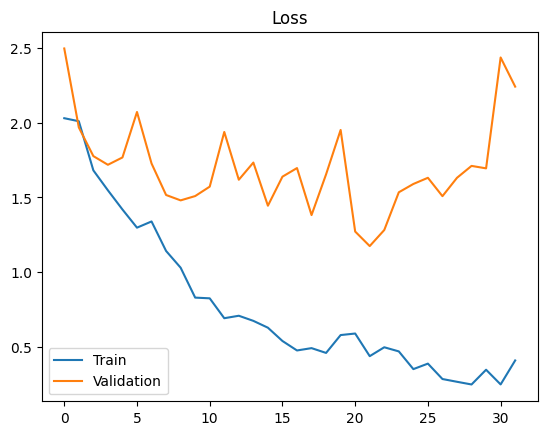

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Conclusion

*   The CNN model successfully learned features from fruit images.
*   Training and validation accuracy improved over epochs.
*   EarlyStopping prevented overfitting.
*   The model achieved good classification performance on unseen data.



